In [ ]:
!pip install nibabel scikit-image batchgenerators
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
from skimage.transform import resize
import os
from glob import glob
import torch.nn.functional as F

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 8.9 MB/s eta 0:00:00
  Created wheel for batchgenerators: filename=batchgenerators-0.25.1-py3-none-any.whl size=93088 sha256=93b61361e973e9a8075f7bee8f81630e6f1c1edc515eaf3d6051d2b229167dbf
  Stored in directory: /root/.cache/pip/wheels/28/21/2b/7b25080f9f5847e6c3162b89d859d7cec9f3093158e56bd008
Successfully built batchgenerators


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

class BratsDataset(Dataset):
    def __init__(self, data_dir, case_dirs, mode='train', patch_size=(96, 96, 96), transform=None):
        """
        Args:
            data_dir: 数据根目录
            case_dirs: 病例目录列表
            mode: 'train', 'val'
            patch_size: 训练时使用的patch尺寸
            transform: 数据增强
        """
        self.data_dir = data_dir
        self.case_dirs = case_dirs
        self.mode = mode
        self.patch_size = patch_size
        self.transform = transform

    def _get_case_dirs(self):
        """获取所有病例的目录路径"""
        pattern = os.path.join(self.data_dir, "BraTS*")
        case_dirs = glob(pattern)
        return [d for d in case_dirs if os.path.isdir(d)]

    # 其他方法保持不变...
    def _load_nifti(self, file_path):
        """加载NIfTI文件并返回numpy数组"""
        img = nib.load(file_path)
        data = img.get_fdata()
        return data, img.affine

    def _normalize(self, data):
        """标准化图像数据"""
        data = np.clip(data, np.percentile(data, 0.5), np.percentile(data, 99.5))
        data = (data - data.mean()) / (data.std() + 1e-8)
        return data

    def _find_modality_files(self, case_dir):
        """查找病例的4个模态文件和分割文件"""
        files = {}

        modalities = {
            't1': '*t1.nii.gz',
            't1ce': '*t1ce.nii.gz',
            't2': '*t2.nii.gz',
            'flair': '*flair.nii.gz',
            'seg': '*seg.nii.gz'  # 分割标签
        }

        for mod, pattern in modalities.items():
            mod_files = glob(os.path.join(case_dir, pattern))
            if mod_files:
                files[mod] = mod_files[0]
            else:
                # 如果是验证模式且缺少分割文件，可以跳过
                if mod == 'seg' and self.mode == 'val':
                    continue
                else:
                    raise FileNotFoundError(f"在 {case_dir} 中找不到 {mod} 文件")

        return files

    def __len__(self):
        return len(self.case_dirs)

    def __getitem__(self, idx):
        case_dir = self.case_dirs[idx]
        files = self._find_modality_files(case_dir)

        # 加载所有模态
        modalities_data = []
        for mod in ['t1', 't1ce', 't2', 'flair']:
            data, affine = self._load_nifti(files[mod])
            data = self._normalize(data)
            modalities_data.append(data)

        # 堆叠模态 (H, W, D, 4)
        image = np.stack(modalities_data, axis=-1)

        # 加载分割标签
        seg_data = np.zeros_like(image[..., 0])  # 默认全零
        if 'seg' in files:
            seg_data, _ = self._load_nifti(files['seg'])
            seg_data = self._remap_seg_labels(seg_data)

        # 调整尺寸到目标patch size
        if image.shape[:3] != self.patch_size:
            image = self._resize_volume(image, self.patch_size)
            seg_data = self._resize_volume(seg_data, self.patch_size, is_seg=True)

        # 转换为PyTorch格式: (C, D, H, W)
        image = torch.from_numpy(image).permute(3, 2, 0, 1).float()  # (4, D, H, W)
        seg_data = torch.from_numpy(seg_data).permute(2, 0, 1).long()  # (D, H, W)

        # 数据增强（仅训练集）
        if self.transform and self.mode == 'train':
            image, seg_data = self.transform(image, seg_data)

        return image, seg_data

    def _remap_seg_labels(self, seg_data):
        """重新映射BraTS标签为连续整数"""
        remapped_seg = np.zeros_like(seg_data)
        remapped_seg[seg_data == 1] = 1  # 坏死
        remapped_seg[seg_data == 2] = 2  # 水肿
        remapped_seg[seg_data == 4] = 3  # 增强肿瘤
        return remapped_seg

    def _resize_volume(self, volume, target_shape, is_seg=False):
        """调整3D体积尺寸"""
        if is_seg:
            order = 0  # 最近邻插值
        else:
            order = 1  # 线性插值

        resized_slices = []
        for i in range(volume.shape[2]):
            if volume.ndim == 4:  # 多模态图像
                slice_resized = resize(volume[:, :, i, :], target_shape[:2], order=order, preserve_range=True)
            else:  # 分割标签
                slice_resized = resize(volume[:, :, i], target_shape[:2], order=order, preserve_range=True)
            resized_slices.append(slice_resized)

        resized_volume = np.stack(resized_slices, axis=2)

        # 调整深度维度
        if resized_volume.shape[2] != target_shape[2]:
            depth_resized = []
            for i in range(resized_volume.shape[0]):
                if volume.ndim == 4:
                    depth_slice = resize(resized_volume[i, :, :, :], (target_shape[1], target_shape[2]), order=order, preserve_range=True)
                else:
                    depth_slice = resize(resized_volume[i, :, :], (target_shape[1], target_shape[2]), order=order, preserve_range=True)
                depth_resized.append(depth_slice)
            resized_volume = np.stack(depth_resized, axis=0)

        return resized_volume

In [ ]:
def create_data_loaders_single_dir(data_dir, batch_size=1, patch_size=(96, 96, 96), val_ratio=0.2):
    """从单一训练目录创建训练和验证数据加载器"""

    # 获取所有病例
    pattern = os.path.join(data_dir, "BraTS*")
    all_case_dirs = [d for d in glob(pattern) if os.path.isdir(d)]

    print(f"找到 {len(all_case_dirs)} 个病例")

    # 分割训练集和验证集
    train_dirs, val_dirs = train_test_split(
        all_case_dirs,
        test_size=val_ratio,
        random_state=42  # 固定随机种子确保可重复性
    )

    print(f"训练集: {len(train_dirs)} 个病例")
    print(f"验证集: {len(val_dirs)} 个病例")

    # 数据集
    train_dataset = BratsDataset(
        data_dir=data_dir,
        case_dirs=train_dirs,
        mode='train',
        patch_size=patch_size,
        transform=BratsTransform(p=0.5)
    )

    val_dataset = BratsDataset(
        data_dir=data_dir,
        case_dirs=val_dirs,
        mode='val',
        patch_size=patch_size,
        transform=None
    )

    # 数据加载器
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0
    )

    return train_loader, val_loader

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
def test_your_data():
    DATA_PATH = "/content/drive/MyDrive/Biomedical/MICCAI_BraTS2020_TrainingData"

    print("正在测试数据...")

    case_pattern = os.path.join(DATA_PATH, "BraTS*")
    case_dirs = glob(case_pattern)
    case_dirs = [d for d in case_dirs if os.path.isdir(d)]

    print(f"找到 {len(case_dirs)} 个病例目录")

    # 检查第一个病例的文件
    first_case = case_dirs[0]
    case_name = os.path.basename(first_case)
    print(f"\n检查病例: {case_name}")

    expected_files = {
        't1': os.path.join(first_case, f"{case_name}_t1.nii"),
        't1ce': os.path.join(first_case, f"{case_name}_t1ce.nii"),
        't2': os.path.join(first_case, f"{case_name}_t2.nii"),
        'flair': os.path.join(first_case, f"{case_name}_flair.nii"),
        'seg': os.path.join(first_case, f"{case_name}_seg.nii")
    }
    print("查找文件:")
    for mod, file_path in expected_files.items():
        exists = os.path.exists(file_path)
        status = "✓" if exists else "✗"
        print(f"  {status} {os.path.basename(file_path)}: {'找到' if exists else '未找到'}")

    # 检查所有必要文件是否存在
    required_files = ['t1', 't1ce', 't2', 'flair', 'seg']
    missing_files = [mod for mod in required_files if not os.path.exists(expected_files[mod])]

    if missing_files:
        print(f"\n缺少文件: {missing_files}")
        # 显示实际存在的文件
        print(f"\n病例目录中的实际文件:")
        for file in os.listdir(first_case):
            print(f"  {file}")
        return False

    print(f"\n✓ 所有文件都已找到!")

    # 测试直接加载一个文件
    print("\n测试直接文件加载...")
    try:
        # 测试加载一个模态
        test_file = expected_files['t1']
        img = nib.load(test_file)
        data = img.get_fdata()
        print(f"✓ 文件加载成功!")
        print(f"  数据维度: {data.shape}")
        print(f"  数据值范围: [{data.min():.1f}, {data.max():.1f}]")
        print(f"  数据类型: {data.dtype}")

        return True

    except Exception as e:
        print(f"文件加载失败: {e}")
        return False

# 运行测试
if __name__ == "__main__":
    test_your_data()

Mounted at /content/drive
正在测试你的数据...
找到 369 个病例目录

检查病例: BraTS20_Training_360
查找文件:
  ✓ BraTS20_Training_360_t1.nii: 找到
  ✓ BraTS20_Training_360_t1ce.nii: 找到
  ✓ BraTS20_Training_360_t2.nii: 找到
  ✓ BraTS20_Training_360_flair.nii: 找到
  ✓ BraTS20_Training_360_seg.nii: 找到

✓ 所有文件都已找到!

测试直接文件加载...
✓ 文件加载成功!
  数据维度: (240, 240, 155)
  数据值范围: [0.0, 536.7]
  数据类型: float64


In [ ]:
class BratsDataset(Dataset):
    def __init__(self, data_dir, case_dirs, mode='train', patch_size=(96, 96, 96), transform=None):
        self.data_dir = data_dir
        self.case_dirs = case_dirs
        self.mode = mode
        self.patch_size = patch_size
        self.transform = transform

    def _load_nifti(self, file_path):
        """加载.nii文件"""
        try:
            img = nib.load(file_path)
            data = img.get_fdata()
            return data, img.affine
        except Exception as e:
            print(f"加载文件失败 {file_path}: {e}")
            raise

    def _normalize(self, data):
        """标准化图像数据"""
        data = np.clip(data, np.percentile(data, 0.5), np.percentile(data, 99.5))
        data = (data - data.mean()) / (data.std() + 1e-8)
        return data

    def _find_modality_files(self, case_dir):
        """查找病例的4个模态文件和分割文件"""
        case_name = os.path.basename(case_dir)
        files = {}

        modalities = {
            't1': f"{case_name}_t1.nii",
            't1ce': f"{case_name}_t1ce.nii",
            't2': f"{case_name}_t2.nii",
            'flair': f"{case_name}_flair.nii",
            'seg': f"{case_name}_seg.nii"
        }

        for mod, filename in modalities.items():
            file_path = os.path.join(case_dir, filename)
            if os.path.exists(file_path):
                files[mod] = file_path
            else:
                # 修复错误信息：显示文件名而不是模态名
                if mod == 'seg' and self.mode == 'val':
                    continue  # 验证集可以没有分割标签
                else:
                    raise FileNotFoundError(f"在 {case_dir} 中找不到文件: {filename}")

        return files

    def __len__(self):
        return len(self.case_dirs)

    def __getitem__(self, idx):
        case_dir = self.case_dirs[idx]
        files = self._find_modality_files(case_dir)

        # 加载所有模态
        modalities_data = []
        for mod in ['t1', 't1ce', 't2', 'flair']:
            data, affine = self._load_nifti(files[mod])
            data = self._normalize(data)
            modalities_data.append(data)

        # 堆叠模态 (H, W, D, 4)
        image = np.stack(modalities_data, axis=-1)

        # 加载分割标签
        seg_data, _ = self._load_nifti(files['seg'])
        seg_data = self._remap_seg_labels(seg_data)

        # 调整尺寸到目标patch size
        if image.shape[:3] != self.patch_size:
            image = self._resize_volume(image, self.patch_size)
            seg_data = self._resize_volume(seg_data, self.patch_size, is_seg=True)

        # 转换为PyTorch格式: (C, D, H, W)
        image = torch.from_numpy(image).permute(3, 2, 0, 1).float()  # (4, D, H, W)
        seg_data = torch.from_numpy(seg_data).permute(2, 0, 1).long()  # (D, H, W)

        # 数据增强（仅训练集）
        if self.transform and self.mode == 'train':
            image, seg_data = self.transform(image, seg_data)

        return image, seg_data

    def _remap_seg_labels(self, seg_data):
        """重新映射BraTS标签为连续整数"""
        remapped_seg = np.zeros_like(seg_data, dtype=np.int64)
        remapped_seg[seg_data == 1] = 1  # 坏死
        remapped_seg[seg_data == 2] = 2  # 水肿
        remapped_seg[seg_data == 4] = 3  # 增强肿瘤
        return remapped_seg

    def _resize_volume(self, volume, target_shape, is_seg=False):
        """调整3D体积尺寸"""
        if is_seg:
            order = 0  # 最近邻插值
        else:
            order = 1  # 线性插值

        # 创建目标形状（保持通道数）
        if volume.ndim == 4:  # 多模态图像
            target_shape_with_channels = target_shape + (volume.shape[3],)
        else:  # 分割标签
            target_shape_with_channels = target_shape

        # 使用skimage.resize调整尺寸
        resized_volume = resize(
            volume,
            target_shape_with_channels,
            order=order,
            preserve_range=True,
            anti_aliasing=not is_seg  # 分割标签不需要抗锯齿
        )

        return resized_volume

# 重新测试修复后的数据集
def test_fixed_dataset():
    DATA_PATH = "/content/drive/MyDrive/Biomedical/MICCAI_BraTS2020_TrainingData"

    print("测试修复后的数据集...")

    # 获取所有病例
    case_dirs = [d for d in glob(os.path.join(DATA_PATH, "BraTS*")) if os.path.isdir(d)]
    print(f"找到 {len(case_dirs)} 个病例")

    # 使用前2个病例进行测试
    test_cases = case_dirs[:2]

    try:
        test_dataset = BratsDataset(
            data_dir=DATA_PATH,
            case_dirs=test_cases,
            mode='train',
            patch_size=(96, 96, 96),
            transform=None
        )

        print("✓ 数据集创建成功!")
        print(f"  数据集大小: {len(test_dataset)} 个样本")

        # 测试所有样本
        for i in range(len(test_dataset)):
            image, seg = test_dataset[i]
            print(f"\n样本 {i}:")
            print(f"  图像维度: {image.shape}")
            print(f"  标签维度: {seg.shape}")
            print(f"  图像值范围: [{image.min():.3f}, {image.max():.3f}]")
            print(f"  标签类别: {torch.unique(seg)}")

        return True

    except Exception as e:
        print(f"数据集测试失败: {e}")
        import traceback
        traceback.print_exc()
        return False

# 运行修复后的测试
test_fixed_dataset()

测试修复后的数据集...
找到 369 个病例
✓ 数据集创建成功!
  数据集大小: 2 个样本

样本 0:
  图像维度: torch.Size([4, 96, 96, 96])
  标签维度: torch.Size([96, 96, 96])
  图像值范围: [-0.337, 5.174]
  标签类别: tensor([0, 1, 2, 3])

样本 1:
  图像维度: torch.Size([4, 96, 96, 96])
  标签维度: torch.Size([96, 96, 96])
  图像值范围: [-0.489, 4.316]
  标签类别: tensor([0, 1, 2, 3])


True

In [ ]:
import random
import torchvision.transforms.functional as F

class BratsTransform:
    """BraTS数据增强类"""
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image, seg):
        """
        Args:
            image: (4, D, H, W) 4模态图像
            seg: (D, H, W) 分割标签
        Returns:
            增强后的图像和标签
        """
        # 随机翻转
        if random.random() < self.p:
            # 随机选择翻转的轴
            axes = [1, 2, 3]  # D, H, W 轴
            flip_axis = random.choice(axes)
            image = torch.flip(image, [flip_axis])
            seg = torch.flip(seg, [flip_axis-1])  # seg没有通道维度

        # 随机旋转 (90°, 180°, 270°)
        if random.random() < self.p:
            k = random.randint(1, 3)  # 旋转次数
            # 在H,W平面旋转
            image = torch.rot90(image, k, dims=[2, 3])
            seg = torch.rot90(seg, k, dims=[1, 2])

        # 随机亮度调整（只对图像，不对标签）
        if random.random() < self.p:
            brightness_factor = random.uniform(0.8, 1.2)
            image = image * brightness_factor

        # 随机高斯噪声
        if random.random() < self.p:
            noise_std = random.uniform(0.0, 0.1)
            noise = torch.randn_like(image) * noise_std
            image = image + noise

        return image, seg

# 重新创建数据加载器（使用完整的数据增强）
def create_brats_data_loaders():
    """创建优化后的数据加载器"""
    DATA_PATH = "/content/drive/MyDrive/Biomedical/MICCAI_BraTS2020_TrainingData"

    # 获取所有病例（不要限制在300个）
    case_dirs = [d for d in glob(os.path.join(DATA_PATH, "BraTS*")) if os.path.isdir(d)]

    # 使用更多数据
    print(f"使用全部 {len(case_dirs)} 个病例")

    # 分割训练验证集
    from sklearn.model_selection import train_test_split
    train_dirs, val_dirs = train_test_split(case_dirs, test_size=0.2, random_state=42)

    print(f"训练集: {len(train_dirs)} 个病例")
    print(f"验证集: {len(val_dirs)} 个病例")

    # 创建数据集 - 可选是否使用数据增强
    train_dataset = BratsDataset(
        data_dir=DATA_PATH,
        case_dirs=train_dirs,
        mode='train',
        patch_size=(96, 96, 96),
        transform=None  # 先关闭数据增强测试速度
    )

    val_dataset = BratsDataset(
        data_dir=DATA_PATH,
        case_dirs=val_dirs,
        mode='val',
        patch_size=(96, 96, 96),
        transform=None
    )

    # 优化配置
    train_loader = DataLoader(
        train_dataset,
        batch_size=2,           # 保持batch_size=2
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(f"训练batches: {len(train_loader)}")
    print(f"验证batches: {len(val_loader)}")

    return train_loader, val_loader


In [ ]:
def test_data_augmentation():
    """测试数据增强效果"""
    DATA_PATH = "/content/drive/MyDrive/Biomedical/MICCAI_BraTS2020_TrainingData"

    case_dirs = [d for d in glob(os.path.join(DATA_PATH, "BraTS*")) if os.path.isdir(d)]
    test_case = case_dirs[0]

    # 创建有数据增强的数据集
    aug_dataset = BratsDataset(
        data_dir=DATA_PATH,
        case_dirs=[test_case],
        mode='train',
        patch_size=(64, 64, 64),
        transform=BratsTransform(p=1.0)  # 100%概率应用增强，便于测试
    )

    print("测试数据增强...")
    original_image, original_seg = aug_dataset[0]  # 会应用增强

    print(f"增强后图像维度: {original_image.shape}")
    print(f"增强后标签维度: {original_seg.shape}")
    print(f"图像值范围: [{original_image.min():.3f}, {original_image.max():.3f}]")
    print(f"标签类别: {torch.unique(original_seg)}")

    # 测试多次增强，观察变化
    print("\n测试多次增强的随机性:")
    for i in range(3):
        aug_image, aug_seg = aug_dataset[0]  # 每次都会随机增强
        print(f"  第{i+1}次 - 图像均值: {aug_image.mean():.3f}, 标签类别: {torch.unique(aug_seg)}")

# 测试数据增强
test_data_augmentation()

测试数据增强...
增强后图像维度: torch.Size([4, 64, 64, 64])
增强后标签维度: torch.Size([64, 64, 64])
图像值范围: [-0.492, 4.778]
标签类别: tensor([0, 1, 2, 3])

测试多次增强的随机性:
  第1次 - 图像均值: 0.000, 标签类别: tensor([0, 1, 2, 3])
  第2次 - 图像均值: 0.000, 标签类别: tensor([0, 1, 2, 3])
  第3次 - 图像均值: -0.000, 标签类别: tensor([0, 1, 2, 3])


In [ ]:
class CachedBratsDataset(BratsDataset):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.cache = {}
        self.loaded_data = {}  # 缓存已加载的原始数据

    def _load_and_preprocess(self, case_dir):
        """缓存加载和预处理结果"""
        if case_dir in self.loaded_data:
            return self.loaded_data[case_dir]

        files = self._find_modality_files(case_dir)

        # 加载所有模态
        modalities_data = []
        for mod in ['t1', 't1ce', 't2', 'flair']:
            data, affine = self._load_nifti(files[mod])
            data = self._normalize(data)
            modalities_data.append(data)

        # 加载分割标签
        seg_data, _ = self._load_nifti(files['seg'])
        seg_data = self._remap_seg_labels(seg_data)

        # 堆叠图像
        image = np.stack(modalities_data, axis=-1)

        # 调整尺寸
        if image.shape[:3] != self.patch_size:
            image = self._resize_volume(image, self.patch_size)
            seg_data = self._resize_volume(seg_data, self.patch_size, is_seg=True)

        result = (image, seg_data)
        self.loaded_data[case_dir] = result
        return result

    def __getitem__(self, idx):
        case_dir = self.case_dirs[idx]

        if idx in self.cache:
            image, seg_data = self.cache[idx]
        else:
            image, seg_data = self._load_and_preprocess(case_dir)
            self.cache[idx] = (image, seg_data)

        # 转换为PyTorch格式
        image = torch.from_numpy(image).permute(3, 2, 0, 1).float()
        seg_data = torch.from_numpy(seg_data).permute(2, 0, 1).long()

        # 数据增强
        if self.transform and self.mode == 'train':
            image, seg_data = self.transform(image, seg_data)

        return image, seg_data


DATA_PATH = "/content/drive/MyDrive/Biomedical/MICCAI_BraTS2020_TrainingData"
# 使用缓存版本
train_dataset = CachedBratsDataset(
    data_dir=DATA_PATH,
    case_dirs = [d for d in glob(os.path.join(DATA_PATH, "BraTS*")) if os.path.isdir(d)],
    mode='train',
    patch_size=(96, 96, 96),
    transform=None  # 先关闭数据增强
)

In [ ]:
# 先定义device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cuda


In [ ]:
class LightMiniUNet(nn.Module):
    """更轻量级的Mini UNet，适用于FA模块"""
    def __init__(self, channels):
        super().__init__()

        # 编码器 - 非常轻量
        self.enc1 = nn.Sequential(
            nn.Conv3d(channels, channels//2, 3, padding=1),
            nn.BatchNorm3d(channels//2),
            nn.ReLU(inplace=True)
        )
        self.pool = nn.MaxPool3d(2)

        # 桥接层
        self.bridge = nn.Sequential(
            nn.Conv3d(channels//2, channels//2, 3, padding=1),
            nn.BatchNorm3d(channels//2),
            nn.ReLU(inplace=True)
        )

        # 解码器
        self.up = nn.ConvTranspose3d(channels//2, channels//2, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv3d(channels, channels, 3, padding=1),  # 跳跃连接后通道数翻倍
            nn.BatchNorm3d(channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # 编码
        e1 = self.enc1(x)          # [B, C/2, D, H, W]
        e1_pool = self.pool(e1)    # [B, C/2, D/2, H/2, W/2]

        # 桥接
        bridge = self.bridge(e1_pool)  # [B, C/2, D/2, H/2, W/2]

        # 解码
        d1 = self.up(bridge)       # [B, C/2, D, H, W]
        d1 = torch.cat([d1, e1], dim=1)  # [B, C, D, H, W]
        output = self.dec1(d1)     # [B, C, D, H, W]

        return output

In [ ]:
class WeightedDiceCELoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        if class_weights is None:
            # 基于标签分布计算权重
            class_weights = torch.tensor([0.1, 10.0, 1.0, 2.0])  # 大幅提高类别1的权重
        self.class_weights = class_weights.to(device)
        self.dice_weight = 0.6
        self.ce_weight = 0.4

    def forward(self, pred, target):
        # 加权交叉熵损失
        ce_loss = F.cross_entropy(pred, target, weight=self.class_weights)

        # Dice损失
        dice_loss = 1 - dice_coefficient(pred, target).mean()

        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

# 使用加权损失
criterion = WeightedDiceCELoss()

In [ ]:
class FrequencyAwareModule(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.norm = nn.LayerNorm(channels)
        self.frequency_weight = nn.Parameter(torch.ones(1, channels, 1, 1, 1))
        self.mini_unet = LightMiniUNet(channels)
        self.conv = nn.Conv3d(channels, channels, 1)

    def forward(self, x):
        identity = x
        B, C, D, H, W = x.shape

        # 层归一化
        x_norm = self.norm(x.permute(0, 2, 3, 4, 1)).permute(0, 4, 1, 2, 3)

        # FFT变换
        x_fft = torch.fft.fftn(x_norm, dim=(-3, -2, -1))
        x_fft_shifted = torch.fft.fftshift(x_fft, dim=(-3, -2, -1))

        # 频域加权
        weighted_fft = x_fft_shifted * self.frequency_weight

        # 逆变换
        weighted_fft_shifted = torch.fft.ifftshift(weighted_fft, dim=(-3, -2, -1))
        x_filtered = torch.fft.ifftn(weighted_fft_shifted, dim=(-3, -2, -1))
        x_filtered = torch.real(x_filtered)

        #Mini UNet特征整合
        x_filtered = self.mini_unet(x_filtered)

        # 残差连接
        return identity + 0.1 * x_filtered

In [ ]:
class FrequencyAwareModule(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.norm = nn.LayerNorm(channels)
        self.frequency_weight = nn.Parameter(torch.ones(1, channels, 1, 1, 1) * 1.0)
        self.mini_unet = LightMiniUNet(channels)
        # 初始化alpha为更大的值
        self.alpha = nn.Parameter(torch.ones(1) * 1.5)
        self.last_fa_contribution = 0

    def forward(self, x):

        '''if self.alpha.item() < 1.0:
            with torch.no_grad():
                self.alpha.data.fill_(1.5)  # 重置为合理值'''

        alpha = torch.sigmoid(self.alpha)

        identity = x
        B, C, D, H, W = x.shape

        # 1. 层归一化 - 论文中提到
        x_norm = self.norm(x.permute(0, 2, 3, 4, 1)).permute(0, 4, 1, 2, 3)

        # 2. FFT变换到频域
        x_fft = torch.fft.fftn(x_norm, dim=(-3, -2, -1))
        x_fft_shifted = torch.fft.fftshift(x_fft, dim=(-3, -2, -1))

        # 3. 频域加权 - 可学习的权重矩阵
        weighted_fft = x_fft_shifted * self.frequency_weight

        # 4. 逆变换回空间域
        weighted_fft_shifted = torch.fft.ifftshift(weighted_fft, dim=(-3, -2, -1))
        x_filtered = torch.fft.ifftn(weighted_fft_shifted, dim=(-3, -2, -1))
        x_filtered = torch.real(x_filtered)

        # 5. 卷积
        x_filtered = self.mini_unet(x_filtered)

        # 计算FA路径的贡献度
        fa_contribution = torch.norm(alpha * x_filtered) / (torch.norm(identity) + 1e-8)
        self.last_fa_contribution = fa_contribution.item()

        # 6. 残差连接 - 使用可学习的alpha控制FA路径贡献
        output = identity + alpha * x_filtered

        return output

    def get_fa_status(self):
        """获取FA模块状态"""
        alpha_value = torch.sigmoid(self.alpha).item()
        return {
            'alpha': alpha_value,
            'alpha_raw': self.alpha.item(),  # 添加原始值监控
            '贡献度': self.last_fa_contribution,
            'frequency_weight_mean': self.frequency_weight.mean().item(),
            'frequency_weight_std': self.frequency_weight.std().item()
        }

In [ ]:
class Conv3DBlock(nn.Module):
    """一个简单的3D卷积块：Conv3D -> BatchNorm -> ReLU"""
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class DoubleConv(nn.Module):
    """标准的双卷积层：ConvBlock -> ConvBlock"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            Conv3DBlock(in_channels, out_channels),
            Conv3DBlock(out_channels, out_channels)
        )

    def forward(self, x):
        return self.double_conv(x)

class Encoder(nn.Module):
    """UNet的编码器部分，负责特征提取和下采样"""
    def __init__(self, in_channels=1, base_channels=32):
        super().__init__()
        self.levels = nn.ModuleList()

        # 定义每个级别的输入输出通道数
        self.channels = [in_channels, base_channels, base_channels*2, base_channels*4, base_channels*8]

        # 创建4个下采样级别
        for i in range(len(self.channels)-1):
            self.levels.append(
                nn.Sequential(
                    DoubleConv(self.channels[i], self.channels[i+1]),
                    nn.MaxPool3d(2)  # 下采样
                )
            )

    def forward(self, x):
        features = []  # 保存每个级别的特征，用于跳跃连接
        current_x = x

        for level in self.levels:
            # 通过双卷积
            conv_output = level[0](current_x)
            features.append(conv_output)  # 保存卷积后的特征（在下采样之前）
            # 下采样
            current_x = level[1](conv_output)

        return features, current_x

class Decoder(nn.Module):
    """UNet的解码器部分，负责上采样和特征融合"""
    def __init__(self, base_channels=32, num_classes=3):
        super().__init__()
        self.up_convs = nn.ModuleList()
        self.upsamples = nn.ModuleList()

        # 解码器的通道数序列（从深层到浅层）
        self.decoder_channels = [
            base_channels * 16,  # bottleneck输出
            base_channels * 8,   # 上采样后与编码器的base_channels*8拼接
            base_channels * 4,   # 上采样后与编码器的base_channels*4拼接
            base_channels * 2,   # 上采样后与编码器的base_channels*2拼接
        ]

        # 创建上采样路径
        for i in range(len(self.decoder_channels)-1):
            # 上采样层
            self.upsamples.append(
                nn.ConvTranspose3d(
                    self.decoder_channels[i],
                    self.decoder_channels[i] // 2,
                    kernel_size=2,
                    stride=2
                )
            )

            # 双卷积层：输入通道数 = 上采样输出 + 对应编码器特征的通道数
            in_ch = (self.decoder_channels[i] // 2) + (base_channels * 8 // (2 ** i))
            out_ch = self.decoder_channels[i+1]
            self.up_convs.append(DoubleConv(in_ch, out_ch))

        # 最终输出层
        self.final_conv = nn.Conv3d(base_channels * 2, num_classes, kernel_size=1)

    def forward(self, features, bottleneck):
        x = bottleneck

        # 反向遍历特征（从深层到浅层）
        for i, (upsample, up_conv) in enumerate(zip(self.upsamples, self.up_convs)):
            # 上采样
            x = upsample(x)

            # 获取对应的编码器特征（从后往前取）
            enc_feat = features[-(i+1)]

            # 调整特征尺寸（确保尺寸匹配）
            if x.shape != enc_feat.shape:
                x = center_crop_or_pad(x, enc_feat.shape[2:])

            # 跳跃连接：拼接编码器和解码器特征
            x = torch.cat([x, enc_feat], dim=1)
            x = up_conv(x)

        return self.final_conv(x)

def center_crop_or_pad(tensor, target_spatial_shape):
    """中心裁剪或填充张量到目标空间形状"""
    _, C, D, H, W = tensor.shape
    target_D, target_H, target_W = target_spatial_shape

    # 计算需要裁剪或填充的量
    diff_D = target_D - D
    diff_H = target_H - H
    diff_W = target_W - W

    if diff_D == 0 and diff_H == 0 and diff_W == 0:
        return tensor

    # 计算裁剪/填充的边界
    start_D = max(-diff_D // 2, 0)
    start_H = max(-diff_H // 2, 0)
    start_W = max(-diff_W // 2, 0)

    end_D = min(D, D - (diff_D + 1) // 2)
    end_H = min(H, H - (diff_H + 1) // 2)
    end_W = min(W, W - (diff_W + 1) // 2)

    # 先裁剪（如果需要）
    cropped = tensor[:, :, start_D:end_D, start_H:end_H, start_W:end_W]

    # 再填充（如果需要）
    if diff_D > 0 or diff_H > 0 or diff_W > 0:
        pad_D = (diff_D // 2, diff_D - diff_D // 2)
        pad_H = (diff_H // 2, diff_H - diff_H // 2)
        pad_W = (diff_W // 2, diff_W - diff_W // 2)
        cropped = F.pad(cropped, (pad_W[0], pad_W[1], pad_H[0], pad_H[1], pad_D[0], pad_D[1]))

    return cropped

In [ ]:
class UNet3D(nn.Module):
    """完整的3D UNet模型 - 修复版本"""
    def __init__(self, in_channels=1, num_classes=3, base_channels=32):
        super().__init__()
        self.encoder = Encoder(in_channels, base_channels)
        self.bottleneck = DoubleConv(base_channels*8, base_channels*16)
        self.decoder = Decoder(base_channels, num_classes)
        self.fa_module = FrequencyAwareModule(base_channels*16)

    def forward(self, x):
        # 保存输入尺寸用于最终上采样
        input_size = x.shape[2:]

        # 编码路径
        features, bottleneck = self.encoder(x)

        # 桥接层
        bottleneck = self.bottleneck(bottleneck)

        # FA模块
        bottleneck = self.fa_module(bottleneck)

        # 解码路径
        output = self.decoder(features, bottleneck)

        # 如果输出尺寸不等于输入尺寸，进行上采样
        if output.shape[2:] != input_size:
            output = torch.nn.functional.interpolate(output, size=input_size, mode='trilinear', align_corners=False)

        return output

In [ ]:
def load_checkpoint_and_continue(model, optimizer, checkpoint_path):
    """加载检查点并继续训练"""
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_dice = checkpoint['best_val_dice']

    print(f"从epoch {start_epoch}恢复训练，最佳Dice: {best_val_dice:.4f}")
    return start_epoch, best_val_dice

In [ ]:
def dice_coefficient(pred, target, smooth=1e-6):
    """简单的Dice系数计算 - 返回标量值"""
    pred = torch.softmax(pred, dim=1)

    dice_total = 0.0
    num_classes = pred.shape[1]

    # 计算每个类别的Dice并求和
    for class_idx in range(num_classes):
        pred_channel = pred[:, class_idx]
        target_channel = (target == class_idx).float()

        intersection = (pred_channel * target_channel).sum()
        union = pred_channel.sum() + target_channel.sum()

        dice = (2. * intersection + smooth) / (union + smooth)
        dice_total += dice

    # 返回所有类别的平均Dice
    return dice_total / num_classes

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DiceCELoss(nn.Module):
    """Dice损失 + CrossEntropy损失的组合"""
    def __init__(self, weight_ce=0.5, weight_dice=0.5):
        super().__init__()
        self.weight_ce = weight_ce
        self.weight_dice = weight_dice
        self.ce = nn.CrossEntropyLoss()

    def forward(self, pred, target):
        # CrossEntropy损失
        ce_loss = self.ce(pred, target)

        # Dice损失 (1 - Dice系数)
        dice_loss = 1 - dice_coefficient(pred, target).mean()

        # 组合损失
        return self.weight_ce * ce_loss + self.weight_dice * dice_loss

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time

# - optim.Adam: 自适应学习率优化器
# - ReduceLROnPlateau: 当验证损失停止改善时自动降低学习率

In [ ]:
def create_brats_model():
    """创建适用于BraTS数据的4模态模型"""

    model = UNet3D(
        in_channels=4,      # 4个模态: t1, t1ce, t2, flair
        num_classes=4,      # 4个类别: 背景(0), 坏死(1), 水肿(2), 增强肿瘤(3)
        base_channels=32    # 基础通道数，控制模型大小
    )

    print("BraTS模型配置:")
    print(f"  输入通道: 4 (t1, t1ce, t2, flair)")
    print(f"  输出类别: 4 (背景, 坏死, 水肿, 增强肿瘤)")
    print(f"  基础通道: 32")
    print(f"  参数量: {sum(p.numel() for p in model.parameters()):,}")

    return model

In [ ]:
def calculate_class_weights(train_loader, num_classes=4):
    """计算基于训练数据的类别权重"""
    class_counts = torch.zeros(num_classes)
    total_samples = 0

    print("计算类别权重...")
    for data, target in train_loader:
        for class_idx in range(num_classes):
            class_counts[class_idx] += (target == class_idx).sum().item()
        total_samples += target.numel()

    class_weights = total_samples / (num_classes * class_counts)
    class_weights = class_weights / class_weights.sum()  # 归一化

    print("类别分布:")
    for i, (count, weight) in enumerate(zip(class_counts, class_weights)):
        names = {0: "背景", 1: "坏死", 2: "水肿", 3: "增强肿瘤"}
        print(f"  {names[i]}: {count:8d}体素, 权重: {weight:.4f}")

    return class_weights

In [ ]:
# 创建数据加载器
print("创建数据加载器...")
train_loader, val_loader = create_brats_data_loaders()

# 检查数据加载器
print(f"训练集批次: {len(train_loader)}")
print(f"验证集批次: {len(val_loader)}")

创建数据加载器...
使用全部 369 个病例
训练集: 295 个病例
验证集: 74 个病例
训练batches: 148
验证batches: 74
训练集批次: 148
验证集批次: 74


In [ ]:
class BalancedWeightedDiceCELoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        if class_weights is None:
            # 更平衡的权重
            class_weights = torch.tensor([0.3, 5.0, 1.0, 2.0])  # 调整
        self.register_buffer('class_weights', class_weights)
        self.dice_weight = 0.7
        self.ce_weight = 0.3

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def setup_live_plotting():
    """设置实时绘图"""
    plt.ion()  # 开启交互模式
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    return fig, (ax1, ax2, ax3, ax4)

def update_live_plots(epoch, train_losses, val_losses, train_dices, val_dices, axes):
    """更新实时图表"""
    ax1, ax2, ax3, ax4 = axes

    # 清除旧图表
    for ax in [ax1, ax2, ax3, ax4]:
        ax.clear()

    epochs_range = range(1, len(train_losses) + 1)

    # 1. 损失曲线
    ax1.plot(epochs_range, train_losses, 'b-', label='训练损失', linewidth=2)
    ax1.plot(epochs_range, val_losses, 'r-', label='验证损失', linewidth=2)
    ax1.set_title('训练和验证损失')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('损失')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Dice系数曲线
    ax2.plot(epochs_range, train_dices, 'b-', label='训练Dice', linewidth=2)
    ax2.plot(epochs_range, val_dices, 'r-', label='验证Dice', linewidth=2)
    ax2.set_title('训练和验证Dice系数')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Dice系数')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)  # Dice范围0-1

    # 3. 学习率变化（如果记录了的话）
    if hasattr(update_live_plots, 'learning_rates'):
        ax3.plot(epochs_range, update_live_plots.learning_rates, 'g-', linewidth=2)
        ax3.set_title('学习率变化')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('学习率')
        ax3.set_yscale('log')
        ax3.grid(True, alpha=0.3)
    else:
        update_live_plots.learning_rates = []
        ax3.text(0.5, 0.5, '学习率数据待更新', ha='center', va='center', transform=ax3.transAxes)

    # 4. 训练进度和统计
    current_epoch = len(train_losses)
    ax4.axis('off')
    stats_text = f"""
    训练进度:
    • 当前Epoch: {current_epoch}
    • 最佳验证Dice: {max(val_dices) if val_dices else 0:.4f}
    • 最新训练Dice: {train_dices[-1] if train_dices else 0:.4f}
    • 最新验证Dice: {val_dices[-1] if val_dices else 0:.4f}
    • 早停计数: {getattr(update_live_plots, 'no_improve_count', 0)}
    """
    ax4.text(0.1, 0.9, stats_text, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

    plt.tight_layout()
    plt.draw()
    plt.pause(0.1)  # 短暂暂停以更新图表

In [ ]:
def check_saved_files():
    """检查保存的文件"""
    checkpoint_dir = "/content/drive/MyDrive/BraTS_Checkpoints/FA_Test"

    if os.path.exists(checkpoint_dir):
        files = os.listdir(checkpoint_dir)
        print("Google Drive中的检查点文件:")
        for file in files:
            file_path = os.path.join(checkpoint_dir, file)
            size = os.path.getsize(file_path) / (1024*1024)  # MB
            print(f"  {file} ({size:.1f} MB)")
    else:
        print("检查点目录不存在")
check_saved_files()

Google Drive中的检查点文件:
  segmentation_epoch_5.png (0.1 MB)
  segmentation_epoch_10.png (0.1 MB)
  segmentation_epoch_15.png (0.1 MB)
  segmentation_epoch_20.png (0.1 MB)
  segmentation_epoch_25.png (0.1 MB)
  First run (0.0 MB)
  Second run (0.0 MB)
  third run (0.0 MB)
  Fourth run (0.0 MB)
  checkpoint_epoch_5.pth (419.5 MB)
  checkpoint_epoch_10.pth (419.5 MB)
  checkpoint_epoch_15.pth (419.5 MB)
  checkpoint_epoch_20.pth (419.5 MB)
  checkpoint_epoch_25.pth (419.5 MB)
  best_model.pth (419.5 MB)
  checkpoint_epoch_30.pth (419.5 MB)
  checkpoint_epoch_35.pth (419.5 MB)
  Fifth run (0.0 MB)


In [ ]:
import torch
import gc


# 重新初始化FA模块 - 这是关键！
def fix_fa_module(model):
    # 重置alpha为更大的值
    for name, param in model.named_parameters():
        if 'alpha' in name and 'fa_module' in name:
            print(f"重置前 {name}: {param.data.item()}")
            with torch.no_grad():
                param.data.fill_(1.2)  # 直接设为0.8，强制FA起作用
            print(f"重置后 {name}: {param.data.item()}")

    # 重新初始化mini_unet
    '''for name, module in model.named_modules():
        if 'mini_unet' in name:
            for layer in module.modules():
                if isinstance(layer, nn.Conv3d):
                    nn.init.kaiming_normal_(layer.weight, mode='fan_out', nonlinearity='relu')
                    if layer.bias is not None:
                        nn.init.constant_(layer.bias, 0.1)  # 小的正偏置'''

In [ ]:
def cleanup():
    torch.cuda.empty_cache()
    gc.collect()

In [ ]:
def main_training_with_visualization(resume_from_checkpoint):
    """带可视化的主训练函数"""
    # 设备配置
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")

    checkpoint_dir = "/content/drive/MyDrive/BraTS_Checkpoints/FA_Test"
    os.makedirs(checkpoint_dir, exist_ok=True)
    print(f"检查点保存路径: {checkpoint_dir}")

    # 设置实时绘图
    fig, axes = setup_live_plotting()

    # 创建模型
    model = create_brats_model().to(device)

    print("=== 优化器参数重新分组 ===")

    # 重新配置优化器，确保正确分组
    fa_alpha_params = []
    fa_mini_unet_params = []
    fa_frequency_params = []
    base_params = []

    for name, param in model.named_parameters():
        if 'fa_module' in name:
            if 'alpha' in name:
                fa_alpha_params.append(param)
                print(f"✓ Alpha参数: {name}")
            elif 'mini_unet' in name:
                fa_mini_unet_params.append(param)
                print(f"✓ Mini_UNet参数: {name}")
            elif 'frequency_weight' in name:
                fa_frequency_params.append(param)
                print(f"✓ Frequency参数: {name}")
            else:
                fa_mini_unet_params.append(param)  # 其他FA参数
                print(f"✓ 其他FA参数: {name}")
        else:
            base_params.append(param)
            print(f"✓ 基础参数: {name}")

    # 打印分组结果确认
    print(f"\n分组统计:")
    print(f"基础参数: {len(base_params)}个")
    print(f"FA-alpha参数: {len(fa_alpha_params)}个")
    print(f"卷积参数: {len(fa_mini_unet_params)}个")
    print(f"FA-frequency参数: {len(fa_frequency_params)}个")

    # 重新创建优化器
    optimizer = torch.optim.Adam([
    {'params': base_params, 'lr': 8e-4},  # 增加权重衰减
    {'params': fa_alpha_params, 'lr': 5e-2},
    {'params': fa_mini_unet_params, 'lr': 1e-2},
    {'params': fa_frequency_params, 'lr': 1e-2},
])

    print("优化器重新配置完成！")

    # 定义优化器和损失函数
    # 为FA模块设置更高的学习率
    '''optimizer = torch.optim.Adam([
    {'params': [p for n, p in model.named_parameters()
                if 'fa_module' not in n], 'lr': 3e-3},
    {'params': [p for n, p in model.named_parameters()
                if 'fa_module' in n and 'alpha' in n], 'lr': 1e-2},
    {'params': [p for n, p in model.named_parameters()
                if 'fa_module' in n and 'mini_unet' in n], 'lr': 5e-3},
    {'params': [p for n, p in model.named_parameters()
                if 'fa_module' in n and 'frequency_weight' in n], 'lr': 3e-3},
])
    '''
    # === 优化器参数组检查 ===
    print("=== 优化器参数组检查 ===")
    for i, param_group in enumerate(optimizer.param_groups):
        print(f"参数组 {i}: LR={param_group['lr']:.2e}, 参数数量: {len(param_group['params'])}")
        # 检查这个参数组是否包含alpha参数
        for param in param_group['params']:
            if param is model.fa_module.alpha:
                print(f"  ✓ 包含alpha参数")

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',           # 监控Dice最大化
        factor=0.5,           # 学习率减半
        patience=3,           # 3个epoch无改善就调整
    )

    # === 使用简单的肿瘤聚焦损失 ===
    class TumorFocusedLoss(nn.Module):
        def __init__(self):
            super().__init__()

        def forward(self, pred, target):
            smooth = 1e-6
            pred = torch.softmax(pred, dim=1)

            # 创建肿瘤mask（所有非背景区域）
            tumor_mask = (target > 0).float()

            # 只计算肿瘤区域的损失
            pred_tumor = pred[:, 1:].sum(dim=1)  # 所有肿瘤类别的概率和
            target_tumor = tumor_mask

            intersection = (pred_tumor * target_tumor).sum()
            union = pred_tumor.sum() + target_tumor.sum()

            dice = (2. * intersection + smooth) / (union + smooth)
            return 1 - dice  # 只优化肿瘤检测

    # 损失函数微调
    criterion = WeightedDiceCELoss(class_weights=torch.tensor([0.2, 6.0, 1.0, 2.5]))

    # 训练参数
    num_epochs = 100
    best_val_dice = 0.0

    # 早停参数
    early_stop_patience = 10
    early_stop_delta = 0.001
    no_improve_count = 0

    # 创建检查点目录
    os.makedirs(checkpoint_dir, exist_ok=True)

    # 恢复训练逻辑
    start_epoch = 0
    train_losses, val_losses = [], []
    train_dices, val_dices = [], []
    learning_rates = []

    if resume_from_checkpoint and os.path.exists(resume_from_checkpoint):
        print(f"从检查点恢复训练: {resume_from_checkpoint}")
        checkpoint = torch.load(resume_from_checkpoint)

        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        # 小幅降低学习率，追求更稳定收敛
        '''for param_group in optimizer.param_groups:
            param_group['lr'] = 8e-5
        print("学习率调整为: 8e-5")'''

        start_epoch = checkpoint['epoch'] + 1
        best_val_dice = checkpoint['best_val_dice']
        train_losses = checkpoint['train_losses']
        val_losses = checkpoint['val_losses']
        train_dices = checkpoint['train_dices']
        val_dices = checkpoint['val_dices']

        print(f"恢复从 epoch {start_epoch} 开始，最佳Dice: {best_val_dice:.4f}")

    print(f"\n开始训练，最多 {num_epochs} 个epochs")
    print(f"早停机制: 连续 {early_stop_patience} 个epochs改善小于 {early_stop_delta} 时停止")
    print("=" * 60)

    # 记录训练过程 - 只在没有恢复训练时初始化
    if not resume_from_checkpoint or not os.path.exists(resume_from_checkpoint):
        train_losses, val_losses = [], []
        train_dices, val_dices = [], []
        learning_rates = []
        start_time = time.time()

    #fix_fa_module(model)

    print("=== FA模块状态检查 ===")
    for name, param in model.named_parameters():
      if 'fa' in name.lower():
        print(f"{name}: requires_grad={param.requires_grad}, shape={param.shape}")


    # 确保FA模块参数可训练
    for param in model.parameters():
      param.requires_grad = True
    print("所有参数已设置为可训练")


    # === 在这里插入步骤3：手动更新测试 ===
    print("=== 手动更新测试 ===")
    with torch.no_grad():
        old_alpha = model.fa_module.alpha.item()
        # 模拟一个梯度更新
        model.fa_module.alpha.data -= 0.1 * torch.ones_like(model.fa_module.alpha)
        new_alpha = model.fa_module.alpha.item()
        print(f"手动更新: {old_alpha:.4f} -> {new_alpha:.4f}")

        # 恢复原值
        model.fa_module.alpha.data += 0.1 * torch.ones_like(model.fa_module.alpha)

    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # === 训练阶段 ===
        model.train()
        train_loss = 0.0
        train_dice = 0.0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()

            # === 在这里插入步骤1：梯度检查 ===
            '''if batch_idx % 20 == 0:  # 每20个batch检查一次
              alpha_grad = model.fa_module.alpha.grad
              if alpha_grad is not None:
                print(f"Alpha梯度: {alpha_grad.item():.8f}")
              else:
                print("Alpha梯度: None - 这问题所在！")

              # 检查其他FA参数的梯度
              for name, param in model.named_parameters():
                if 'fa_module' in name and param.grad is not None:
                  grad_norm = param.grad.norm().item()
                  print(f"  {name}梯度范数: {grad_norm:.8f}")'''

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)


            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5

            if total_norm > 1000:  # 梯度太大了！
                print(f"梯度爆炸警告: {total_norm}")

            optimizer.step()

            dice = dice_coefficient(output, target).mean()

            train_loss += loss.item()
            train_dice += dice.item()

            if batch_idx % 20 == 0:
                print(f'  Batch {batch_idx:3d}/{len(train_loader)}, Loss: {loss.item():.4f}, Dice: {dice.item():.4f}')

            # 在训练循环中替换现有的FA监控
            if batch_idx % 20 == 0:
              with torch.no_grad():
                alpha_val = model.fa_module.alpha.item()
                fa_contrib = model.fa_module.last_fa_contribution

                print(f"FA状态 - alpha: {alpha_val:.4f}, 贡献度: {fa_contrib:.6f}")

                # 检查FA路径是否真的有影响
                if fa_contrib < 1e-4:
                  print(" FA贡献度过低，考虑增加alpha初始值")

        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_dice = train_dice / len(train_loader)
        train_losses.append(epoch_train_loss)
        train_dices.append(epoch_train_dice)

        # === 验证阶段 ===
        model.eval()
        val_loss = 0.0
        val_dice = 0.0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                dice = dice_coefficient(output, target).mean()

                val_loss += loss.item()
                val_dice += dice.item()

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_dice = val_dice / len(val_loader)
        val_losses.append(epoch_val_loss)
        val_dices.append(epoch_val_dice)

        cleanup()

        # 记录学习率
        current_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(current_lr)
        update_live_plots.learning_rates = learning_rates

        # 早停逻辑
        improvement = epoch_val_dice - best_val_dice
        update_live_plots.no_improve_count = no_improve_count

        if improvement > early_stop_delta:
            best_val_dice = epoch_val_dice
            no_improve_count = 0

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_dice': best_val_dice,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_dices': train_dices,
                'val_dices': val_dices,
                'learning_rates': learning_rates
            }
            torch.save(checkpoint, os.path.join(checkpoint_dir, 'best_model.pth'))
            print(f"保存最佳模型，验证Dice: {best_val_dice:.4f} (+{improvement:.4f})")

        else:
            no_improve_count += 1
            print(f"无显著改善，计数: {no_improve_count}/{early_stop_patience}")

            if no_improve_count >= early_stop_patience:
                print(f"触发早停：连续 {early_stop_patience} 个epochs无显著改善")
                break

        # 调整学习率
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(epoch_val_dice)
        new_lr = optimizer.param_groups[0]['lr']

        if new_lr < old_lr:
            print(f"学习率从 {old_lr:.2e} 降低到 {new_lr:.2e}")

        epoch_time = time.time() - epoch_start
        print(f"训练 - Loss: {epoch_train_loss:.4f}, Dice: {epoch_train_dice:.4f}")
        print(f"验证 - Loss: {epoch_val_loss:.4f}, Dice: {epoch_val_dice:.4f}")
        print(f"时间: {epoch_time:.1f}s")

        if (epoch + 1) % 5 == 0:  # 每5个epoch保存一次
            checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth')
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_dice': best_val_dice,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_dices': train_dices,
                'val_dices': val_dices,
                'learning_rates': learning_rates
            }
            torch.save(checkpoint, checkpoint_path)
            print(f"检查点已保存到Google Drive: {checkpoint_path}")
            print(f"\n生成分割效果示意图 (Epoch {epoch+1})...")
            try:
                seg_fig = visualize_segmentation(model, val_loader, device, num_samples=2)
                seg_fig.savefig(f'/content/drive/MyDrive/BraTS_Checkpoints/segmentation_epoch_{epoch+1}.png',
                              dpi=150, bbox_inches='tight')
                plt.close(seg_fig)
                print(f" 分割示意图已保存")
            except Exception as e:
                print(f" 分割可视化失败: {e}")

        # 最佳模型也保存到Google Drive
        if epoch_val_dice > best_val_dice + early_stop_delta:
            best_checkpoint_path = os.path.join(checkpoint_dir, 'best_model.pth')
            torch.save(checkpoint, best_checkpoint_path)
            print(f"最佳模型已保存到Google Drive: {best_checkpoint_path}")

    # 训练结束后保存最终图表
    plt.savefig('/content/training_curves.png', dpi=300, bbox_inches='tight')
    print("训练曲线已保存为 /content/training_curves.png")

    total_time = time.time() - start_time
    actual_epochs = epoch + 1

    print(f"\n训练完成! 实际运行 {actual_epochs} 个epochs")
    print(f"总时间: {total_time/60:.1f}分钟")
    print(f"最佳验证Dice: {best_val_dice:.4f}")

    plt.ioff()  # 关闭交互模式
    plt.show()  # 显示最终图表

    return model, train_losses, val_losses, train_dices, val_dices

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_segmentation(model, dataloader, device, num_samples=3):
    """可视化分割结果"""
    model.eval()

    # 获取几个样本
    samples = []
    for i, (data, target) in enumerate(dataloader):
        if i >= num_samples:
            break
        samples.append((data, target))

    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    colors = ['black', 'red', 'green', 'blue']  # 背景, 坏死, 水肿, 增强肿瘤

    with torch.no_grad():
        for i, (data, target) in enumerate(samples):
            data, target = data.to(device), target.to(device)
            output = model(data)
            prediction = torch.softmax(output, dim=1)
            pred_mask = torch.argmax(prediction, dim=1)

            # 获取中间切片
            slice_idx = data.shape[2] // 2  # 深度方向的中间切片

            # 原始图像 (FLAIR模态)
            original_slice = data[0, 3, slice_idx].cpu().numpy()  # FLAIR是第4个模态

            # 真实标签
            gt_slice = target[0, slice_idx].cpu().numpy()

            # 预测结果
            pred_slice = pred_mask[0, slice_idx].cpu().numpy()

            # 置信度 (肿瘤类别的最大概率)
            confidence_slice = prediction[0, 1:4, slice_idx].max(dim=0)[0].cpu().numpy()

            # 绘制结果
            axes[i, 0].imshow(original_slice, cmap='gray')
            axes[i, 0].set_title('FLAIR')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(original_slice, cmap='gray')
            axes[i, 1].imshow(gt_slice, cmap='tab10', alpha=0.5, vmin=0, vmax=3)
            axes[i, 1].set_title('real_segmentation')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(original_slice, cmap='gray')
            axes[i, 2].imshow(pred_slice, cmap='tab10', alpha=0.5, vmin=0, vmax=3)
            axes[i, 2].set_title('predicted_segmentation')
            axes[i, 2].axis('off')

            axes[i, 3].imshow(confidence_slice, cmap='hot', vmin=0, vmax=1)
            axes[i, 3].set_title('confidence')
            axes[i, 3].axis('off')

            # 重叠比较
            axes[i, 4].imshow(original_slice, cmap='gray')
            # 用不同颜色显示正确和错误的分割
            correct_mask = (pred_slice == gt_slice) & (gt_slice > 0)  # 正确预测的肿瘤区域
            wrong_mask = (pred_slice != gt_slice) & (gt_slice > 0)    # 错误预测的肿瘤区域
            false_positive = (pred_slice > 0) & (gt_slice == 0)       # 假阳性

            # 创建彩色叠加
            overlay = np.zeros((*pred_slice.shape, 3))
            overlay[correct_mask] = [0, 1, 0]   # 绿色：正确
            overlay[wrong_mask] = [1, 0, 0]     # 红色：错误
            overlay[false_positive] = [1, 1, 0] # 黄色：假阳性

            axes[i, 4].imshow(overlay, alpha=0.6)
            axes[i, 4].set_title('correct_green/wrong_red/fake_positive_yellow')
            axes[i, 4].axis('off')

    plt.tight_layout()
    return fig

创建数据加载器...
使用全部 369 个病例
训练集: 295 个病例
验证集: 74 个病例
训练batches: 148
验证batches: 74

开始带实时可视化的FA-UNet训练
使用设备: cuda
检查点保存路径: /content/drive/MyDrive/BraTS_Checkpoints/FA_Test
BraTS模型配置:
  输入通道: 4 (t1, t1ce, t2, flair)
  输出类别: 4 (背景, 坏死, 水肿, 增强肿瘤)
  基础通道: 32
  参数量: 35,399,941
=== 优化器参数重新分组 ===
✓ 基础参数: encoder.levels.0.0.double_conv.0.block.0.weight
✓ 基础参数: encoder.levels.0.0.double_conv.0.block.0.bias
✓ 基础参数: encoder.levels.0.0.double_conv.0.block.1.weight
✓ 基础参数: encoder.levels.0.0.double_conv.0.block.1.bias
✓ 基础参数: encoder.levels.0.0.double_conv.1.block.0.weight
✓ 基础参数: encoder.levels.0.0.double_conv.1.block.0.bias
✓ 基础参数: encoder.levels.0.0.double_conv.1.block.1.weight
✓ 基础参数: encoder.levels.0.0.double_conv.1.block.1.bias
✓ 基础参数: encoder.levels.1.0.double_conv.0.block.0.weight
✓ 基础参数: encoder.levels.1.0.double_conv.0.block.0.bias
✓ 基础参数: encoder.levels.1.0.double_conv.0.block.1.weight
✓ 基础参数: encoder.levels.1.0.double_conv.0.block.1.bias
✓ 基础参数: encoder.levels.1.0.double_conv.1.block.0.weigh

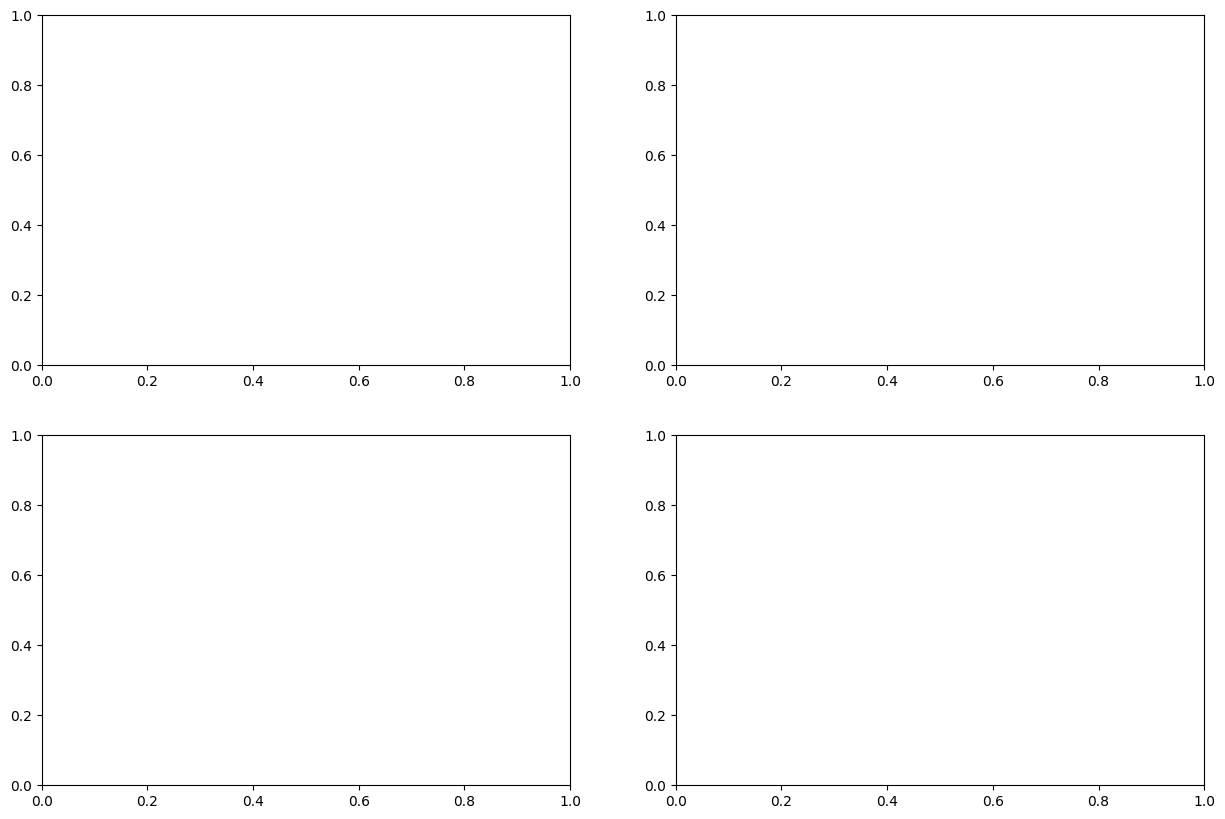

In [ ]:
# 首先创建数据加载器
print("创建数据加载器...")
train_loader, val_loader = create_brats_data_loaders()

print("\n" + "="*50)
print("开始带实时可视化的FA-UNet训练")
print("="*50)

# 开始训练！
resume_from_checkpoint = None

model, train_losses, val_losses, train_dices, val_dices = main_training_with_visualization(resume_from_checkpoint)

恢复训练（学习率已重置）...
使用设备: cuda
检查点保存路径: /content/drive/MyDrive/BraTS_Checkpoints/FA_Test
BraTS模型配置:
  输入通道: 4 (t1, t1ce, t2, flair)
  输出类别: 4 (背景, 坏死, 水肿, 增强肿瘤)
  基础通道: 32
  参数量: 36,642,821
=== 优化器参数重新分组 ===
✓ 基础参数: encoder.levels.0.0.double_conv.0.block.0.weight
✓ 基础参数: encoder.levels.0.0.double_conv.0.block.0.bias
✓ 基础参数: encoder.levels.0.0.double_conv.0.block.1.weight
✓ 基础参数: encoder.levels.0.0.double_conv.0.block.1.bias
✓ 基础参数: encoder.levels.0.0.double_conv.1.block.0.weight
✓ 基础参数: encoder.levels.0.0.double_conv.1.block.0.bias
✓ 基础参数: encoder.levels.0.0.double_conv.1.block.1.weight
✓ 基础参数: encoder.levels.0.0.double_conv.1.block.1.bias
✓ 基础参数: encoder.levels.1.0.double_conv.0.block.0.weight
✓ 基础参数: encoder.levels.1.0.double_conv.0.block.0.bias
✓ 基础参数: encoder.levels.1.0.double_conv.0.block.1.weight
✓ 基础参数: encoder.levels.1.0.double_conv.0.block.1.bias
✓ 基础参数: encoder.levels.1.0.double_conv.1.block.0.weight
✓ 基础参数: encoder.levels.1.0.double_conv.1.block.0.bias
✓ 基础参数: encoder.levels.1.0

UnboundLocalError: cannot access local variable 'start_time' where it is not associated with a value

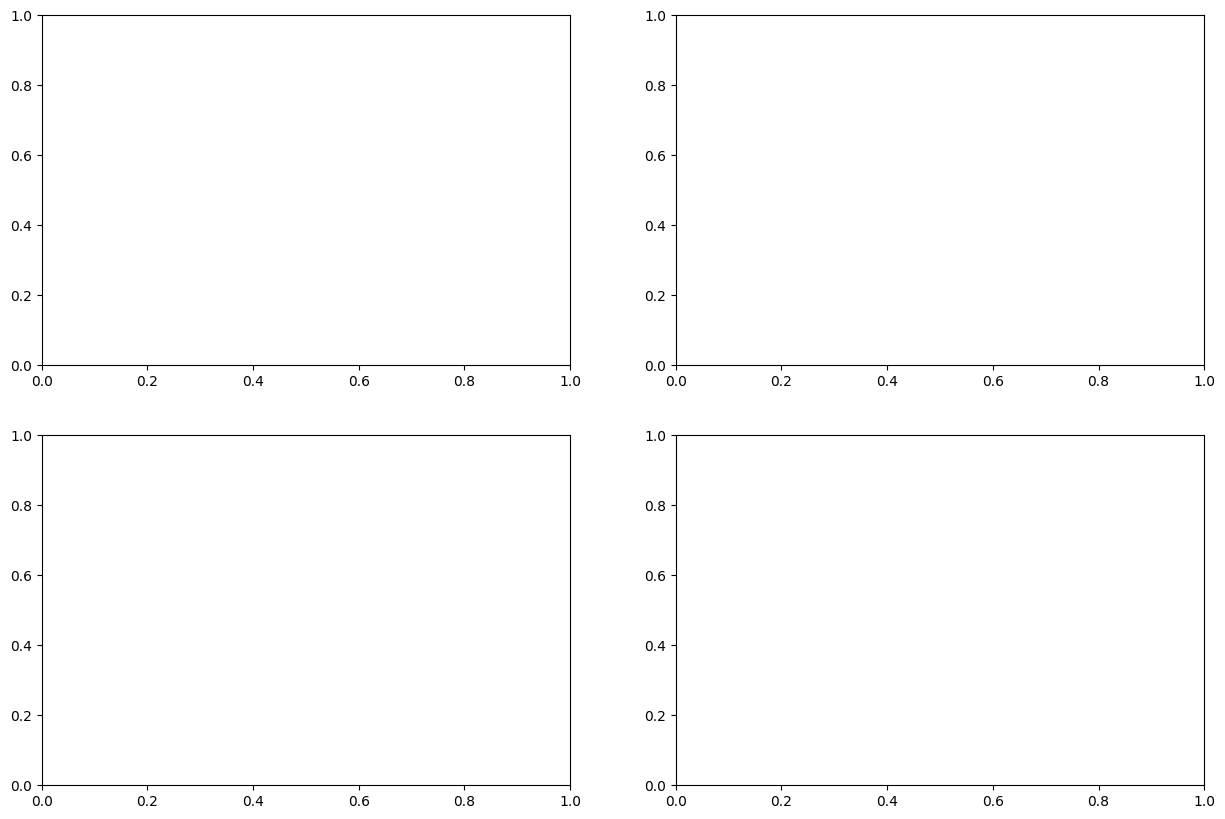

In [ ]:
checkpoint_path = "/content/drive/MyDrive/BraTS_Checkpoints/FA_Test/best_model.pth"

print("恢复训练（学习率已重置）...")
model, train_losses, val_losses, train_dices, val_dices = main_training_with_visualization(
    resume_from_checkpoint=checkpoint_path
)

In [ ]:
# 在下一个epoch开始时运行
def debug_fa_module():
    model.eval()
    with torch.no_grad():
        sample_batch = next(iter(val_loader))
        output, attention_info = model(sample_batch, return_attention=True)

        print("=== FA模块诊断 ===")
        print(f"基础输出范围: [{output.min():.3f}, {output.max():.3f}]")
        for i, attn in enumerate(attention_info):
            attn_flat = attn.flatten()
            # 分析注意力分布
            quantiles = torch.quantile(attn_flat, torch.tensor([0.1, 0.5, 0.9]))
            print(f"FA_{i}: 10%={quantiles[0]:.3f}, 50%={quantiles[1]:.3f}, "
                  f"90%={quantiles[2]:.3f}, 激活率={(attn > 0.5).float().mean():.3f}")


debug_fa_module()

In [ ]:

def analyze_final_results(model, dataloader, device):
    """训练结束后的详细分析"""
    print("\n" + "="*50)
    print("最终结果分析")
    print("="*50)

    # 可视化多个样本
    fig = visualize_segmentation(model, dataloader, device, num_samples=4)
    fig.savefig('/content/drive/MyDrive/BraTS_Checkpoints/final_segmentation_results.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # 计算详细指标
    model.eval()
    total_dice = 0.0
    total_samples = 0

    dice_per_class = {1: 0.0, 2: 0.0, 3: 0.0}  # 坏死, 水肿, 增强肿瘤

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            # 计算每个类别的Dice
            for class_id in [1, 2, 3]:
                dice = dice_coefficient_per_class(output, target, class_id)
                dice_per_class[class_id] += dice.item()

            total_dice += dice_coefficient(output, target).mean().item()
            total_samples += 1

    # 打印详细结果
    print("\n 各类别性能分析:")
    print(f"总体Dice: {total_dice/total_samples:.4f}")
    for class_id, dice_sum in dice_per_class.items():
        class_names = {1: '坏死', 2: '水肿', 3: '增强肿瘤'}
        print(f"{class_names[class_id]} Dice: {dice_sum/total_samples:.4f}")

def dice_coefficient_per_class(pred, target, class_id, smooth=1e-6):
    """计算单个类别的Dice系数"""
    pred_class = (torch.softmax(pred, dim=1)[:, class_id] > 0.5).float()
    target_class = (target == class_id).float()

    intersection = (pred_class * target_class).sum()
    union = pred_class.sum() + target_class.sum()

    return (2. * intersection + smooth) / (union + smooth)

analyze_final_results(model, val_loader, device)

In [ ]:
# 简化调试版本 - 不依赖外部导入
def simple_debug():
    """简化调试 - 只检查数据和标签"""
    print("=== 数据标签调试 ===")

    # 1. 数据检查
    data, target = next(iter(train_loader))
    print(f"1. 输入数据: {data.shape}, 范围: [{data.min():.3f}, {data.max():.3f}]")

    # 2. 标签检查
    unique, counts = torch.unique(target, return_counts=True)
    label_dist = dict(zip(unique.tolist(), counts.tolist()))
    print(f"2. 标签分布: {label_dist}")

    # 3. 计算类别权重建议
    total_voxels = sum(label_dist.values())
    print(f"3. 总体素数: {total_voxels}")

    # 建议的类别权重（逆频率）
    suggested_weights = {}
    for class_id, count in label_dist.items():
        weight = total_voxels / (len(label_dist) * count)  # 逆频率加权
        suggested_weights[class_id] = weight
        print(f"   类别 {class_id}: {count}体素 → 建议权重: {weight:.2f}")

    return suggested_weights

# 运行简化调试
suggested_weights = simple_debug()

In [ ]:
import time
print("\n=== 数据加载器性能测试 ===")

# 测试纯数据加载（不训练）
model = create_brats_model().to(device)
model.eval()

with torch.no_grad():
    start_time = time.time()
    batch_count = 0

    for i, (data, target) in enumerate(train_loader):
        if i >= 5:  # 只测试5个batch
            break

        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target)

        batch_count += 1
        if i % 1 == 0:
            current_time = time.time() - start_time
            print(f"Batch {i}: {current_time/(i+1):.1f}s/batch")

    total_time = time.time() - start_time
    print(f"\n平均速度: {total_time/batch_count:.1f}秒/batch")
    print(f"预计每个epoch: {(total_time/batch_count)*len(train_loader)/60:.1f}分钟")


=== 数据加载器性能测试 ===
BraTS模型配置:
  输入通道: 4 (t1, t1ce, t2, flair)
  输出类别: 4 (背景, 坏死, 水肿, 增强肿瘤)
  基础通道: 32
  参数量: 35,662,596
Batch 0: 23.2s/batch
Batch 1: 12.5s/batch
Batch 2: 12.1s/batch
Batch 3: 12.1s/batch
Batch 4: 12.9s/batch

平均速度: 17.2秒/batch
预计每个epoch: 42.4分钟


In [ ]:
# 从保存的检查点读取
checkpoint_path = "/content/drive/MyDrive/BraTS_Checkpoints/best_model.pth"
checkpoint = torch.load(checkpoint_path)

print("检查点中的优化器状态:")
optimizer_state = checkpoint['optimizer_state_dict']
print(f"学习率: {optimizer_state['param_groups'][0]['lr']:.2e}")

检查点中的优化器状态:
学习率: 1.00e-05
